In [93]:
import numpy as np
import matplotlib.pyplot as plt
import time

***Problem 1***

***Problem 2***

Runtime: 0.36491360000036366 seconds


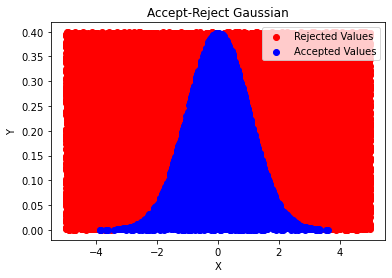

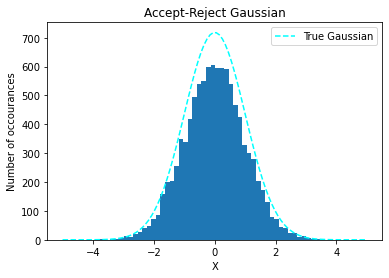

In [97]:
#Accept-Reject Method
#For this method we generate a random number and compare it to the Gaussian to see if it is within or outside
#Let's just do a Uniform envelope function
#Last pages of Lecture 6 notes

#Let's define a Gaussian function
def Gaussian(x, mean, sigma):
    return(1/(sigma * np.sqrt(2*np.pi))*np.exp(-1/2 * ((x-mean)/(sigma))**2))

AcceptedValues=[]
RejectedValues=[]


mean=0
sigma=1
loopLimit = 10000

timeStart=time.perf_counter()

while(len(AcceptedValues) < loopLimit):

    inputs = np.random.random() * 10 - 5 #Just going to move this from [0, 1) to [-5, 5)
    GaussianValues = Gaussian(inputs, mean, sigma)
    comparisonValues=np.random.random() / (sigma*np.sqrt(2*np.pi)) #making this go from 0 to max(Gaussian)

    if(comparisonValues > GaussianValues):
        RejectedValues.append([inputs, comparisonValues])
    elif(comparisonValues <= GaussianValues):
        AcceptedValues.append([inputs, comparisonValues])
    else:
        print('This should never print')

tempx=[]
tempy=[]
for i in range(len(RejectedValues)):
    tempx.append(RejectedValues[i][0])
    tempy.append(RejectedValues[i][1])
plt.scatter(tempx, tempy, color='red', label='Rejected Values')

tempx=[] #man I hate this, lemme itterate on this and see if there is a better way
tempy=[]
for i in range(len(AcceptedValues)):
    tempx.append(AcceptedValues[i][0])
    tempy.append(AcceptedValues[i][1])
    
timeStop=time.perf_counter()
runtime = timeStop - timeStart
print('Runtime: '+str(runtime)+' seconds')

plt.scatter(tempx, tempy, color='blue', label='Accepted Values')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Accept-Reject Gaussian')
plt.legend()
plt.show()

plt.hist(tempx, bins=50)
plt.plot(np.linspace(-5, 5, 100), 1800*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Accept-Reject Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

Runtime: 0.07054260000040813 seconds


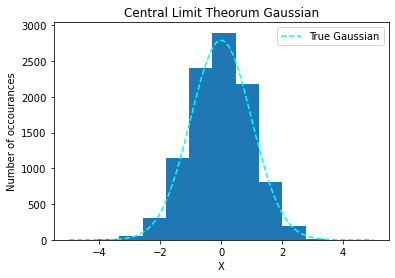

In [98]:
#Central Limit Theorum
#The uniform distribution has average 1/2, variance 1/12
#making N uniform numbers, that collection has average N/2, variance N/12
#we want N to be 12, so variance will now be 1. Then we nudge it by N/2 to set the mean to 0
loopLimit=10000
gaussianValues=[]
timeStart=time.perf_counter()
for i in range(loopLimit):
    N=12
    values = np.random.random(N)
    gaussianValues.append(np.sum(values) - N/2)
    
timeStop=time.perf_counter()
runtime = timeStop - timeStart
print('Runtime: '+str(runtime)+' seconds')

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 7000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Central Limit Theorum Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

Runtime: 0.04970250000042142 seconds


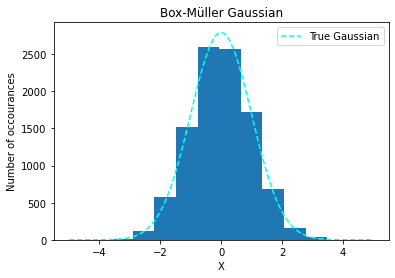

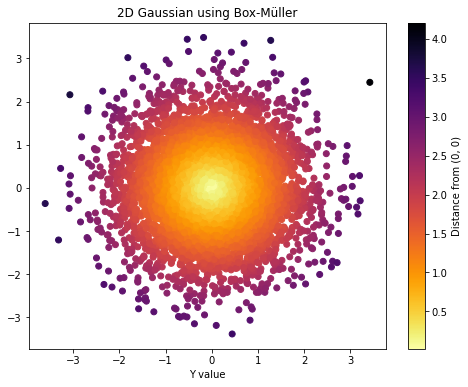

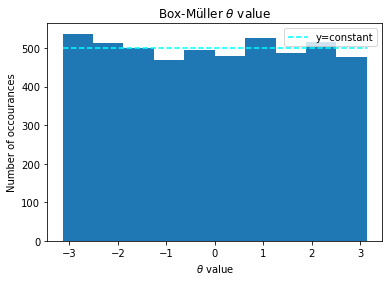

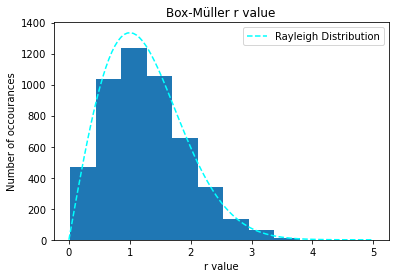

In [99]:
#Box-Mueller
loopLimit=10000
gaussianValues=[]
xvalues=[]
yvalues=[]

timeStart=time.perf_counter()

while len(gaussianValues) < loopLimit:
    u=np.random.random()
    v=np.random.random()
    x=np.sqrt(-2*np.log(u))*np.cos(2*np.pi*v)
    y=np.sqrt(-2*np.log(u))*np.sin(2*np.pi*v)
    xvalues.append(x)
    yvalues.append(y)
    gaussianValues.append(x)
    gaussianValues.append(y)
    
timeStop=time.perf_counter()
runtime = timeStop - timeStart
print('Runtime: '+str(runtime)+' seconds')

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 7000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Box-Müller Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6)) #maybe I should compute the actual covariance for x and y
plt.scatter(xvalues, yvalues, c=np.sqrt(np.array(xvalues)**2+np.array(yvalues)**2), cmap='inferno_r')
plt.title('2D Gaussian using Box-Müller')
plt.xlabel('X value')
plt.xlabel('Y value')
plt.colorbar(label='Distance from (0, 0)')
plt.show()

#Now let's show what r and theta look like. We have the x and y values so we can just do the things
rvalues=np.sqrt(np.array(xvalues)**2+np.array(yvalues)**2)
thetavalues=np.arctan2(np.array(xvalues), np.array(yvalues))
plt.hist(thetavalues)
plt.plot([-np.pi, np.pi], [500, 500], label='y=constant', linestyle='--', color='cyan')
plt.title(r'Box-Müller $\theta$ value')
plt.xlabel(r'$\theta$ value')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

def Rayleigh(x, sigma):
    return(x/(sigma**2)*np.exp(-x**2/(2*sigma**2)))

plt.hist(rvalues)
plt.plot(np.linspace(0, 5, 100), 2200*Rayleigh(np.linspace(0, 5, 100), 1), label='Rayleigh Distribution', linestyle='--', color='cyan')
plt.title('Box-Müller r value')
plt.xlabel('r value')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

Runtime: 0.05181570000058855 seconds


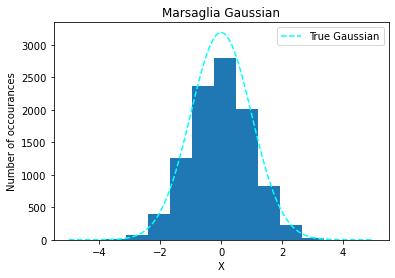

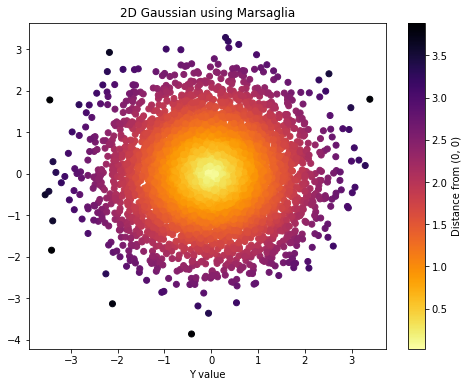

In [100]:
#Marsaglia Method
loopLimit=10000
gaussianValues=[]
xvalues=[]
yvalues=[]

timeStart=time.perf_counter()

while len(gaussianValues) < loopLimit:
    u=np.random.random()
    v=np.random.random()
    x=2*u - 1
    y=2*v - 1
    s=x**2+y**2
    if(s>1):
        pass
    else:
        x=np.sqrt(-2 * np.log(s)) * x/np.sqrt(s)
        y=np.sqrt(-2 * np.log(s)) * y/np.sqrt(s)
        xvalues.append(x)
        yvalues.append(y)
        gaussianValues.append(x)
        gaussianValues.append(y)

timeStop=time.perf_counter()
runtime = timeStop - timeStart
print('Runtime: '+str(runtime)+' seconds')

plt.hist(gaussianValues)
plt.plot(np.linspace(-5, 5, 100), 8000*Gaussian(np.linspace(-5, 5, 100), 0, 1), linestyle='--', color='cyan', label = 'True Gaussian')
plt.title('Marsaglia Gaussian')
plt.xlabel('X')
plt.ylabel('Number of occourances')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6)) #maybe I should compute the actual covariance for x and y
plt.scatter(xvalues, yvalues, c=np.sqrt(np.array(xvalues)**2+np.array(yvalues)**2), cmap='inferno_r')
plt.title('2D Gaussian using Marsaglia')
plt.xlabel('X value')
plt.xlabel('Y value')
plt.colorbar(label='Distance from (0, 0)')
plt.show()

***Problem 3***

In [31]:
np.random.rand(10000)

array([0.20647745, 0.305085  , 0.88294659, ..., 0.35579809, 0.04871606,
       0.6991206 ])